In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [ ]:
# ==========================================
# 1. KONFIGURASI PARAMETER (TERKALIBRASI PRESISI)
# ==========================================
start_date = date(2023, 1, 1)
end_date = date(2045, 12, 31)
days = (end_date - start_date).days + 1

# --- A. Historis Wisatawan & Kapasitas Fisik ---
kapasitas_pengunjung_harian = 2752
lama_tinggal = 3

dom_2023, man_2023 = 355297, 13210
dom_2024, man_2024 = 465751, 19926
dom_2025_est = 390487 * (12 / 9)
man_2025_est = 13300 * (12 / 9)

r_dom_23_24 = (dom_2024 / dom_2023) ** (1 / 365) - 1
r_man_23_24 = (man_2024 / man_2023) ** (1 / 365) - 1
r_dom_24_25 = (dom_2025_est / dom_2024) ** (1 / 365) - 1
r_man_24_25 = (man_2025_est / man_2024) ** (1 / 365) - 1
daily_growth_bau = (1 + 0.0468) ** (1 / 365) - 1

# --- B. Parameter Harga (Intervensi Demand) ---
elasticity = -0.504
price_dom_old = ((5 * 54000) + (2 * 79000)) / 7
price_man_old = 255000
price_dom_new = ((5 * 58320) + (2 * 90850)) / 7
price_man_new = 318750
shock_dom = ((price_dom_new - price_dom_old) / price_dom_old) * elasticity
shock_man = ((price_man_new - price_man_old) / price_man_old) * elasticity
daily_growth_int = (1 + 0.035) ** (1 / 365) - 1

# --- C. Parameter Fiskal Umum ---
persentase_retribusi = 0.85
initial_stock_anggaran = 3_976_500_000
rasio_penyerapan_harian = 1 - (1 - 0.90)**(1/365)

# --- D. Parameter Kualitas Layanan (DIKALIBRASI) ---
initial_skill_stock = 712
decay_rate_harian = 1 - (1 - 0.18)**(1/365)  # Kedaluwarsa ilmu 18% per tahun
target_standar = 80
skill_point_per_training = 1.5  # Pertumbuhan gradual (tidak instan)

# BAU SDM
alokasi_pelatihan_bau = 0.015     # Hanya 1.5% dari belanja
biaya_pelatihan_bau = 3_000_000

# INTERVENSI SDM
alokasi_pelatihan_int = 0.03      # 3% dari belanja
biaya_pelatihan_int = 2_000_000

In [ ]:
# ==========================================
# 2. MESIN SIMULASI (CAUSAL LOOP INTEGRATED)
# ==========================================
dates = []
data_indeks_bau, data_indeks_int = [], []

curr_dom_bau, curr_man_bau = dom_2023 / 365, man_2023 / 365
curr_dom_int, curr_man_int = dom_2023 / 365, man_2023 / 365

budget_bau, budget_int = initial_stock_anggaran, initial_stock_anggaran
skill_bau, skill_int = initial_skill_stock, initial_skill_stock

reputasi_bau, reputasi_int = 1.0, 1.0
curr_date = start_date

for _ in range(days):
    dates.append(curr_date)
    year = curr_date.year

    # 1. GROWTH RATES & CROWDING EFFECT
    if year == 2023:
        g_dom_bau, g_man_bau = r_dom_23_24, r_man_23_24
        g_dom_int, g_man_int = r_dom_23_24, r_man_23_24
    elif year == 2024:
        g_dom_bau, g_man_bau = r_dom_24_25, r_man_24_25
        g_dom_int, g_man_int = r_dom_24_25, r_man_24_25
    else:
        g_dom_bau, g_man_bau = daily_growth_bau, daily_growth_bau
        if year == 2026 and curr_date == date(2026, 1, 1):
            curr_dom_int *= (1 + shock_dom)
            curr_man_int *= (1 + shock_man)
        elif year >= 2026:
            g_dom_int, g_man_int = daily_growth_int, daily_growth_int
        else:
            g_dom_int, g_man_int = daily_growth_bau, daily_growth_bau

    pop_bau = curr_dom_bau + curr_man_bau
    if pop_bau > kapasitas_pengunjung_harian:
        reputasi_bau -= (pop_bau / kapasitas_pengunjung_harian - 1.0) * 0.0004
    reputasi_bau = max(0.80, reputasi_bau)

    pop_int = curr_dom_int + curr_man_int
    if pop_int > kapasitas_pengunjung_harian:
        reputasi_int -= (pop_int / kapasitas_pengunjung_harian - 1.0) * 0.0004
    reputasi_int = max(0.80, reputasi_int)

    out_bau_dom, out_bau_man = curr_dom_bau / lama_tinggal, curr_man_bau / lama_tinggal
    in_bau_dom = (out_bau_dom + curr_dom_bau * g_dom_bau) * reputasi_bau
    in_bau_man = (out_bau_man + curr_man_bau * g_man_bau) * reputasi_bau
    curr_dom_bau += (in_bau_dom - out_bau_dom)
    curr_man_bau += (in_bau_man - out_bau_man)

    out_int_dom, out_int_man = curr_dom_int / lama_tinggal, curr_man_int / lama_tinggal
    if year >= 2026:
        in_int_dom = (out_int_dom + curr_dom_int * g_dom_int) * reputasi_int
        in_int_man = (out_int_man + curr_man_int * g_man_int) * reputasi_int
    else:
        in_int_dom = (out_int_dom + curr_dom_int * g_dom_bau) * reputasi_int
        in_int_man = (out_int_man + curr_man_int * g_man_bau) * reputasi_int
    curr_dom_int += (in_int_dom - out_int_dom)
    curr_man_int += (in_int_man - out_int_man)

    # 2. FISKAL & KUALITAS (BAU)
    rev_bau = ((curr_dom_bau * price_dom_old) + (curr_man_bau * price_man_old)) * persentase_retribusi
    belanja_bau = budget_bau * rasio_penyerapan_harian
    budget_bau = max(0, budget_bau + rev_bau - belanja_bau)

    anggaran_pelatihan_bau = belanja_bau * alokasi_pelatihan_bau
    trained_bau = anggaran_pelatihan_bau / biaya_pelatihan_bau
    skill_bau = skill_bau + (trained_bau * skill_point_per_training) - (skill_bau * decay_rate_harian)
    skill_bau = max(0, min(1000, skill_bau)) # Cap 0-1000
    data_indeks_bau.append(skill_bau / 10)

    # 3. FISKAL & KUALITAS (INTERVENSI)
    price_dom_curr = price_dom_new if year >= 2026 else price_dom_old
    price_man_curr = price_man_new if year >= 2026 else price_man_old
    rev_int = ((curr_dom_int * price_dom_curr) + (curr_man_int * price_man_curr)) * persentase_retribusi
    belanja_int = budget_int * rasio_penyerapan_harian
    budget_int = max(0, budget_int + rev_int - belanja_int)

    alokasi_curr = alokasi_pelatihan_int if year >= 2026 else alokasi_pelatihan_bau
    biaya_curr = biaya_pelatihan_int if year >= 2026 else biaya_pelatihan_bau

    anggaran_pelatihan_int = belanja_int * alokasi_curr
    trained_int = anggaran_pelatihan_int / biaya_curr
    skill_int = skill_int + (trained_int * skill_point_per_training) - (skill_int * decay_rate_harian)
    skill_int = max(0, min(1000, skill_int)) # Cap 0-1000
    data_indeks_int.append(skill_int / 10)

    curr_date += timedelta(days=1)

In [ ]:
# ==========================================
# 3. DATAFRAME & VISUAL SMOOTHING
# ==========================================
df = pd.DataFrame({"Date": pd.to_datetime(dates), "Indeks_BAU": data_indeks_bau, "Indeks_INT": data_indeks_int})

# Visual smoothing
df["BAU_Smooth"] = df["Indeks_BAU"].rolling(window=180, min_periods=1, center=True).mean()
df["INT_Smooth"] = df["Indeks_INT"].rolling(window=180, min_periods=1, center=True).mean()

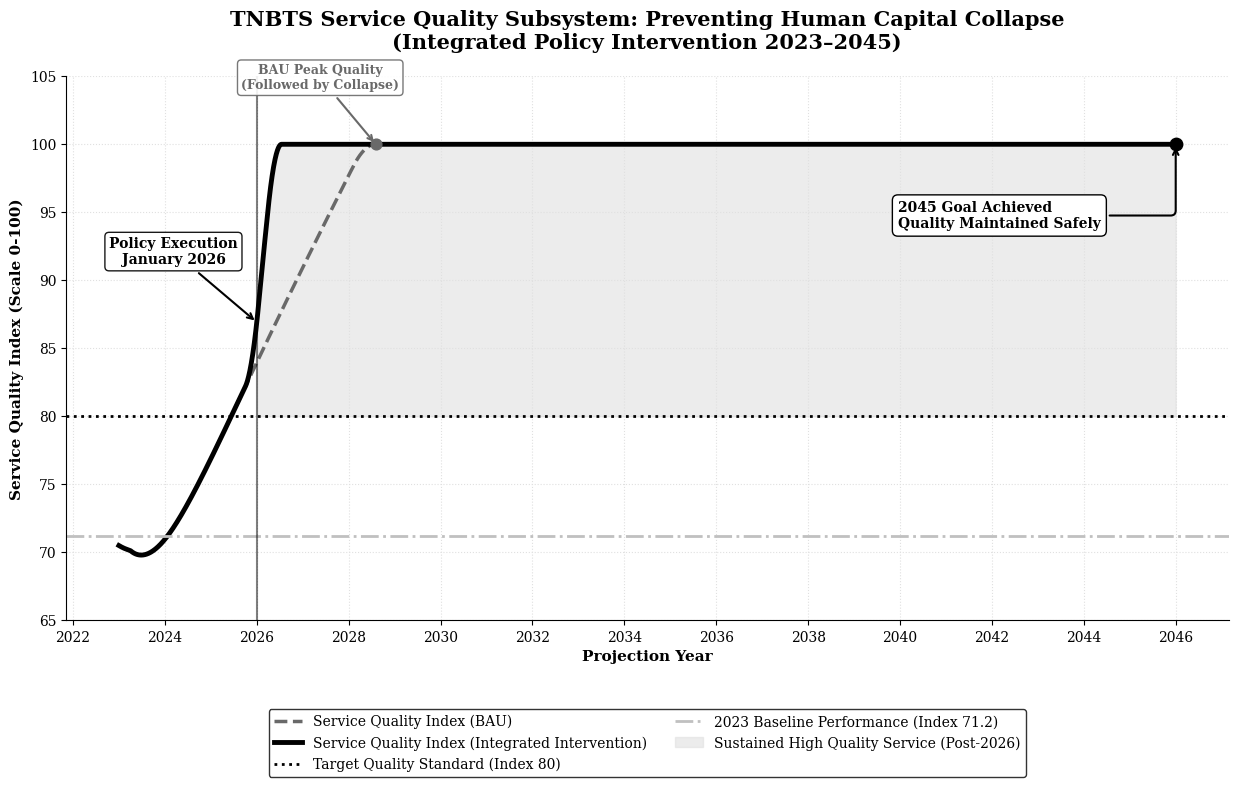

In [ ]:
# ==========================================
# 4. VISUALISASI MONOKROM AKADEMIS (ENGLISH)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif', 'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black',
    'ytick.color': 'black', 'axes.grid': True, 'grid.color': '#e0e0e0',
    'grid.linestyle': ':', 'legend.frameon': True, 'legend.edgecolor': 'black'
})

fig, ax = plt.subplots(figsize=(15, 8))
plt.subplots_adjust(bottom=0.20)

# Plot Garis
ax.plot(df["Date"], df["BAU_Smooth"], color="dimgray", linestyle="--", linewidth=2.5, label="Service Quality Index (BAU)")
ax.plot(df["Date"], df["INT_Smooth"], color="black", linestyle="-", linewidth=3.5, label="Service Quality Index (Integrated Intervention)")

# Garis Referensi
ax.axhline(y=target_standar, color="black", linestyle=":", linewidth=2, label=f"Target Quality Standard (Index {target_standar})")
ax.axhline(y=71.2, color="silver", linestyle="-.", linewidth=2, label="2023 Baseline Performance (Index 71.2)")

# Arsiran Kesuksesan (Hanya saat Intervensi di atas standar)
df_shaded = df[df["Date"] >= pd.Timestamp("2026-01-01")]
ax.fill_between(df_shaded["Date"], df_shaded["INT_Smooth"], target_standar,
                where=(df_shaded["INT_Smooth"] >= target_standar),
                color="#e0e0e0", alpha=0.6, label="Sustained High Quality Service (Post-2026)")

# ------------------------------------------
# ANOTASI: INTERVENSI 2026
# ------------------------------------------
batas_intervensi = pd.Timestamp("2026-01-01")
val_2026 = df.loc[df["Date"] == batas_intervensi, "INT_Smooth"].values[0]

ax.axvline(x=batas_intervensi, color="black", linestyle="-", linewidth=1.5, alpha=0.5)
ax.annotate(
    "Policy Execution\nJanuary 2026",
    xy=(batas_intervensi, val_2026), xytext=(-60, 40), textcoords="offset points",
    fontsize=10, weight='bold', ha="center", va="bottom",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9)
)

# ------------------------------------------
# ANOTASI: BENCANA KUALITAS BAU
# ------------------------------------------
# Cari titik puncak BAU
peak_bau_date = df.loc[df["BAU_Smooth"].idxmax(), "Date"]
val_peak_bau = df["BAU_Smooth"].max()

ax.scatter(peak_bau_date, val_peak_bau, color="dimgray", s=60, zorder=5)
ax.annotate(
    f"BAU Peak Quality\n(Followed by Collapse)",
    xy=(peak_bau_date, val_peak_bau), xytext=(-40, 40), textcoords="offset points",
    fontsize=9, weight='bold', color='dimgray', ha="center",
    arrowprops=dict(arrowstyle="->", color="dimgray", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="dimgray", alpha=0.9)
)

# ------------------------------------------
# ANOTASI: KEBERHASILAN INTERVENSI 2045
# ------------------------------------------
end_date = df["Date"].iloc[-1]
end_val_int = df["INT_Smooth"].iloc[-1]
ax.scatter(end_date, end_val_int, color="black", s=80, zorder=6)
ax.annotate(
    "2045 Goal Achieved\nQuality Maintained Safely",
    xy=(end_date, end_val_int), xytext=(-200, -60), textcoords="offset points",
    fontsize=10, weight='bold', color='black',
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5, connectionstyle="angle,angleA=0,angleB=90,rad=5"),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=1.0)
)

# Formatting
ax.set_title("TNBTS Service Quality Subsystem: Preventing Human Capital Collapse\n(Integrated Policy Intervention 2023–2045)", fontsize=15, fontweight="bold", pad=20)
ax.set_xlabel("Projection Year", fontsize=11, fontweight="bold")
ax.set_ylabel("Service Quality Index (Scale 0-100)", fontsize=11, fontweight="bold")

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylim(bottom=65, top=105)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=10, frameon=True, facecolor="white", edgecolor="black")

plt.show()

In [ ]:
# ==========================================
# 5. EVALUASI MAPE: SUBSISTEM KUALITAS LAYANAN (SDM)
# ==========================================

# 1. Agregasi data harian Indeks BAU menjadi rata-rata tahunan
df['Year'] = df['Date'].dt.year
df_kualitas_tahunan = df.groupby('Year').agg(
    Indeks_Simulasi=('Indeks_BAU', 'mean')
).reset_index()

# 2. Masukkan Data Aktual (Riil) Indeks Kualitas Layanan
# CATATAN: Tahun 2023 menggunakan baseline Anda (71.2).
# Silakan ganti nilai 2024 dengan data hasil kuesioner, review, atau penilaian riil jika ada.
data_aktual_kualitas = {
    2023: 71.20,
    2024: 71.80   # Angka dummy, silakan disesuaikan dengan tren data lapangan
}

df_aktual_kualitas = pd.DataFrame(list(data_aktual_kualitas.items()), columns=['Year', 'Aktual_Indeks'])

# 3. Gabungkan dan Hitung MAPE
df_eval_kualitas = pd.merge(df_aktual_kualitas, df_kualitas_tahunan, on='Year', how='inner')
df_eval_kualitas['APE'] = np.abs((df_eval_kualitas['Aktual_Indeks'] - df_eval_kualitas['Indeks_Simulasi']) / df_eval_kualitas['Aktual_Indeks']) * 100
mape_kualitas = df_eval_kualitas['APE'].mean()

# 4. Tampilkan Hasil Evaluasi Kualitas Layanan
print("\n" + "="*75)
print("     EVALUASI MAPE: SUBSISTEM KUALITAS LAYANAN (INDEKS SDM)")
print("="*75)
print(df_eval_kualitas[['Year', 'Aktual_Indeks', 'Indeks_Simulasi', 'APE']].rename(
    columns={'Aktual_Indeks': 'Aktual (Skala 100)', 'Indeks_Simulasi': 'Simulasi (Skala 100)', 'APE': 'Error (%)'}
).round(2).to_string(index=False))
print("-" * 75)
print(f"NILAI MAPE SUBSISTEM KUALITAS : {mape_kualitas:.2f}%")

if mape_kualitas < 10:
    kategori_kualitas = "Sangat Akurat (Highly Accurate)"
elif mape_kualitas < 20:
    kategori_kualitas = "Baik (Good)"
elif mape_kualitas < 50:
    kategori_kualitas = "Cukup (Reasonable)"
else:
    kategori_kualitas = "Kurang Akurat (Inaccurate)"

print(f"KATEGORI AKURASI              : {kategori_kualitas}")
print("=" * 75)


     EVALUASI MAPE: SUBSISTEM KUALITAS LAYANAN (INDEKS SDM)
 Year  Aktual (Skala 100)  Simulasi (Skala 100)  Error (%)
 2023                71.2                 70.13        1.5
 2024                71.8                 73.67        2.6
---------------------------------------------------------------------------
NILAI MAPE SUBSISTEM KUALITAS : 2.05%
KATEGORI AKURASI              : Sangat Akurat (Highly Accurate)
